In [1]:
import torch
import numpy as np
from torch.func import functional_call, jacrev
from pyDOE import lhs
import matplotlib.pyplot as plt

from lm_train.network import DNN
from lm_train.training_module import training_LM

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
def model_uv(data, params):
    """Helper to evaluate the model on a single point for vmap."""
    return functional_call(model, params, (data.unsqueeze(0), )).squeeze(0)

def loss_pde(params, *args, **kwargs):
    """
    Multi-dimensional PDE residual (2 equations).
    """
    t, = args
    alpha = kwargs.get('alpha', 1.0)
    beta = kwargs.get('beta', 1.0)
    
    jac = jacrev(model_uv, argnums=0)(t, params) 
    
    u, v = model_uv(t, params)
    u_t, v_t = jac[0, 0], jac[1, 0]
    
    f_u = u_t - alpha * v
    f_v = v_t + beta * u
    
    return torch.stack([f_u, f_v])

def loss_ic(params, *args, **kwargs):
    """Initial Condition loss for both variables."""
    t, target = args
    output = model_uv(t, params)
    
    assert output.shape == target.shape, 'The shape of output and target should match'
    return output - target

In [3]:
torch.set_default_dtype(torch.float64)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

n_points_d = 512
n_epoch = 2000

t_domain = torch.tensor(lhs(1, n_points_d)) * 2 * np.pi
t_domain = t_domain.to(device)

t_ic = torch.tensor([[0.0]]).to(device)
target_ic = torch.tensor([[1.0, 0.0]]).to(device)

model = DNN([1, 32, 32, 2]).to(device)
params = dict(model.named_parameters())
for p in params.values():
    p.requires_grad = False

losses = [loss_pde, loss_ic]
inputs = [
    [t_domain],
    [t_ic, target_ic]
]
kwargs = [
    {'alpha': 2.0, 'beta': 2.0}, 
    {}
]

args = tuple(zip(losses, inputs, kwargs))

In [4]:
params, lossval_all, loss_running, lossval_test = training_LM(
    params,
    device,
    args,
    steps=n_epoch,
    writePercent=10,
)

Step: 200. loss: 7.1046e-04. mu: 7.4363e-05.
Step: 400. loss: 6.2345e-12. mu: 6.6358e-14.
Step: 600. loss: 4.9166e-13. mu: 2.1483e-14.
Step: 800. loss: 1.9072e-14. mu: 4.1730e-14.
Step: 1000. loss: 1.0598e-15. mu: 8.1059e-14.
Step: 1200. loss: 1.6247e-16. mu: 2.6242e-14.
Step: 1400. loss: 1.3423e-16. mu: 5.0975e-14.
Step: 1600. loss: 1.3423e-16. mu: 1.6503e-14.
Step: 1800. loss: 1.3423e-16. mu: 3.2056e-14.
Step: 2000. loss: 8.9111e-17. mu: 6.2268e-14.
training time: 25.158769369125366 (s).


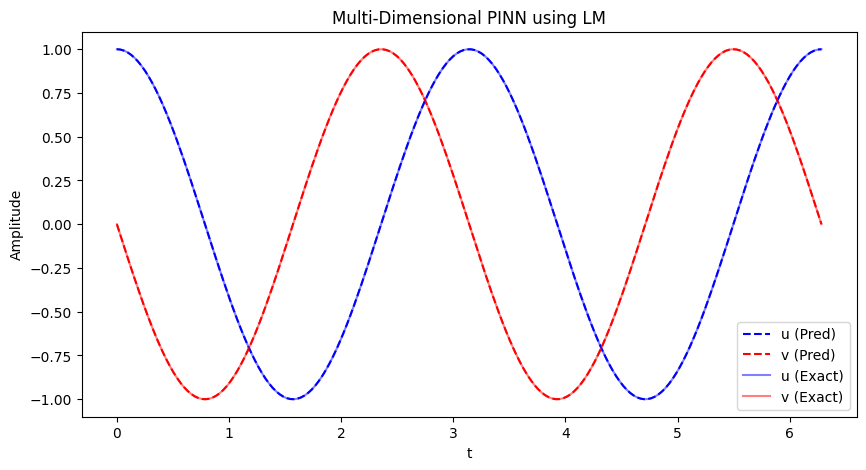

In [5]:
model.load_state_dict(params)
model.eval()

t_test = torch.linspace(0, 2*np.pi, 200).unsqueeze(1).to(device)
with torch.no_grad():
    uv_pred = model(t_test).cpu().numpy()

t_plot = t_test.cpu().numpy()
u_pred = uv_pred[:, 0]
v_pred = uv_pred[:, 1]

# Exact solution for alpha=2, beta=2 is u=cos(2t), v=-sin(2t)
u_exact = np.cos(2 * t_plot)
v_exact = -np.sin(2 * t_plot)

plt.figure(figsize=(10, 5))
plt.plot(t_plot, u_pred, 'b--', label='u (Pred)')
plt.plot(t_plot, v_pred, 'r--', label='v (Pred)')
plt.plot(t_plot, u_exact, 'b-', alpha=0.5, label='u (Exact)')
plt.plot(t_plot, v_exact, 'r-', alpha=0.5, label='v (Exact)')
plt.xlabel('t')
plt.ylabel('Amplitude')
plt.legend()
plt.title('Multi-Dimensional PINN using LM')
plt.show()